# Walmart Sales Forecasting Project
## Time Series Forecasting & Regression

**Dataset:** Walmart Sales Forecast (Kaggle)  
**Objective:** Predict future sales based on historical sales data

**Covered Topics:**
- Time series forecasting
- Regression modeling
- Feature engineering (time-based features, lag values)
- Rolling averages & seasonal decomposition
- XGBoost/LightGBM with time-aware validation

##setup & Installation

In [2]:
!pip install xgboost lightgbm -q

## Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb

from statsmodels.tsa.seasonal import seasonal_decompose
from google.colab import files
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)

## Step 1: Upload Your Walmart Dataset

In [4]:
uploaded = files.upload()

Saving features.csv to features.csv
Saving stores.csv to stores.csv
Saving train.csv to train.csv


## Step 2: Load and Merge Dataset




In [5]:
train = pd.read_csv('train.csv')
features = pd.read_csv('features.csv')
stores = pd.read_csv('stores.csv')

print(f"\ntrain.csv shape: {train.shape}")
print(f"features.csv shape: {features.shape}")
print(f"stores.csv shape: {stores.shape}")

print("\nTrain data sample:")
display(train.head())

print("\nFeatures data sample:")
display(features.head())

print("\nStores data sample:")
display(stores.head())


train.csv shape: (421570, 5)
features.csv shape: (8190, 12)
stores.csv shape: (45, 3)

Train data sample:


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False



Features data sample:


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False



Stores data sample:


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [6]:
df = train.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
df = df.merge(stores, on='Store', how='left')
print(f"Merged dataset shape: {df.shape}")
print(f"\nDate range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Number of stores: {df['Store'].nunique()}")
print(f"Number of departments: {df['Dept'].nunique()}")
print(f"Total records: {len(df):,}")

df['Date'] = pd.to_datetime(df['Date'])

print("\nMerged dataset columns:")
print(df.columns.tolist())

print("\nFirst few rows of merged data:")
df.head(10)

Merged dataset shape: (421570, 16)

Date range: 2010-02-05 to 2012-10-26
Number of stores: 45
Number of departments: 81
Total records: 421,570

Merged dataset columns:
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size']

First few rows of merged data:


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315
5,1,1,2010-03-12,21043.39,False,57.79,2.667,NaN,NaN,NaN,NaN,NaN,211.380643,8.106,A,151315
6,1,1,2010-03-19,22136.64,False,54.58,2.720,NaN,NaN,NaN,NaN,NaN,211.215635,8.106,A,151315
7,1,1,2010-03-26,26229.21,False,51.45,2.732,NaN,NaN,NaN,NaN,NaN,211.018042,8.106,A,151315
8,1,1,2010-04-02,57258.43,False,62.27,2.719,NaN,NaN,NaN,NaN,NaN,210.820450,7.808,A,151315
9,1,1,2010-04-09,42960.91,False,65.86,2.770,NaN,NaN,NaN,NaN,NaN,210.622857,7.808,A,151315


## Step 3: Exploratory Data Analysis

In [7]:
print("Dataset Info:")
df.info()
print("\nStatistical Summary:")
display(df.describe())

missing = df.isnull().sum()
missing_df = missing[missing > 0].sort_values(ascending=False)
if len(missing_df) > 0:
    print("Missing values found:")
    print(missing_df)
else:
    print("No missing values found!")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  object        
 15  Siz

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.258123,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289,136727.915739
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,34875.000000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000,93638.000000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000,140167.000000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000,202505.000000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000
std,12.785297,30.492054,NaN,22711.183519,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296,60980.583328


Missing values found:
MarkDown2    310322
MarkDown4    286603
MarkDown3    284479
MarkDown1    270889
MarkDown5    270138
dtype: int64


In [8]:
markdown_cols = [col for col in df.columns if 'MarkDown' in col]
for col in markdown_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)
        print(f"Filled {col} with 0")

numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())
        print(f"Filled {col} with median")

print(f"Remaining missing values: {df.isnull().sum().sum()}")

Filled MarkDown1 with 0
Filled MarkDown2 with 0
Filled MarkDown3 with 0
Filled MarkDown4 with 0
Filled MarkDown5 with 0
Remaining missing values: 0


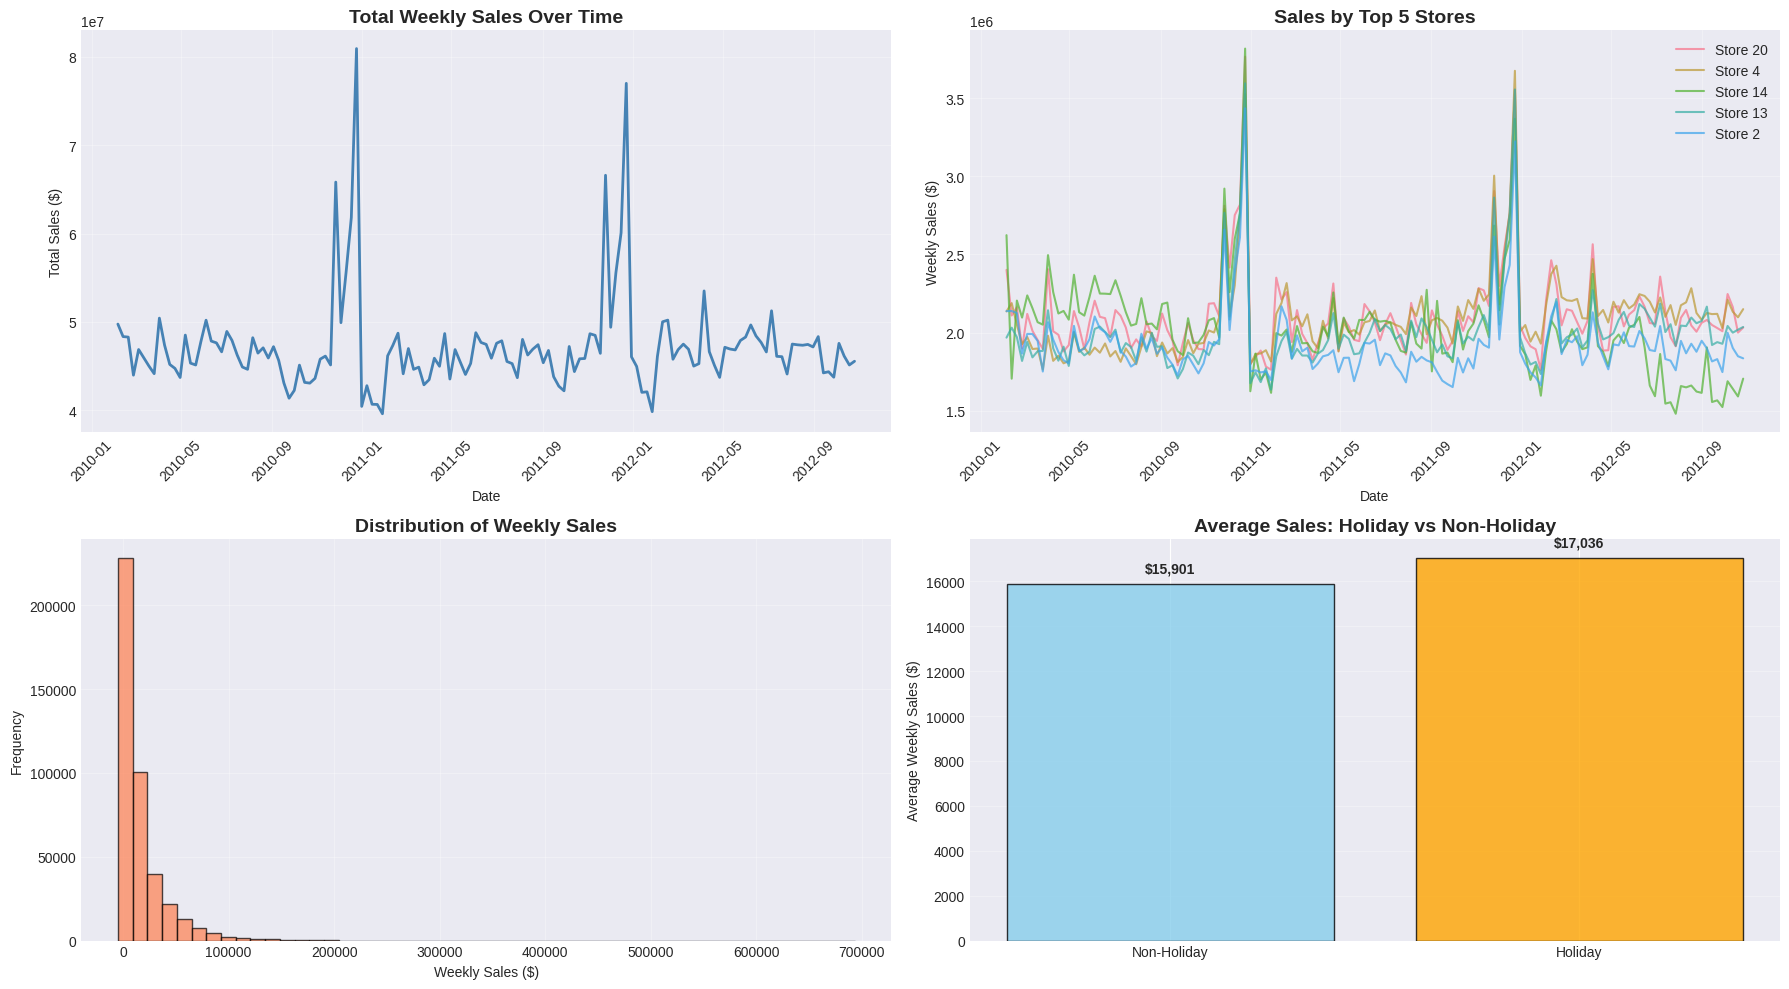


Holiday sales are 7.1% higher than non-holiday sales


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

sales_by_date = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
axes[0, 0].plot(sales_by_date['Date'], sales_by_date['Weekly_Sales'],
                linewidth=2, color='steelblue')
axes[0, 0].set_title('Total Weekly Sales Over Time', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Total Sales ($)')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

top_stores = df.groupby('Store')['Weekly_Sales'].sum().nlargest(10).index
for store in top_stores[:5]:
    store_data = df[df['Store'] == store].groupby('Date')['Weekly_Sales'].sum()
    axes[0, 1].plot(store_data.index, store_data.values, label=f'Store {store}', alpha=0.7)
axes[0, 1].set_title('Sales by Top 5 Stores', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Weekly Sales ($)')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

axes[1, 0].hist(df['Weekly_Sales'], bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Distribution of Weekly Sales', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Weekly Sales ($)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(alpha=0.3)

holiday_sales = df.groupby('IsHoliday')['Weekly_Sales'].mean()
axes[1, 1].bar(['Non-Holiday', 'Holiday'], holiday_sales.values,
               color=['skyblue', 'orange'], alpha=0.8, edgecolor='black')
axes[1, 1].set_title('Average Sales: Holiday vs Non-Holiday', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Average Weekly Sales ($)')
axes[1, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate(holiday_sales.values):
    axes[1, 1].text(i, v + 500, f'${v:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

if len(holiday_sales) > 1:
    pct_diff = ((holiday_sales.iloc[1]/holiday_sales.iloc[0] - 1) * 100)
    print(f"\nHoliday sales are {pct_diff:.1f}% {'higher' if pct_diff > 0 else 'lower'} than non-holiday sales")

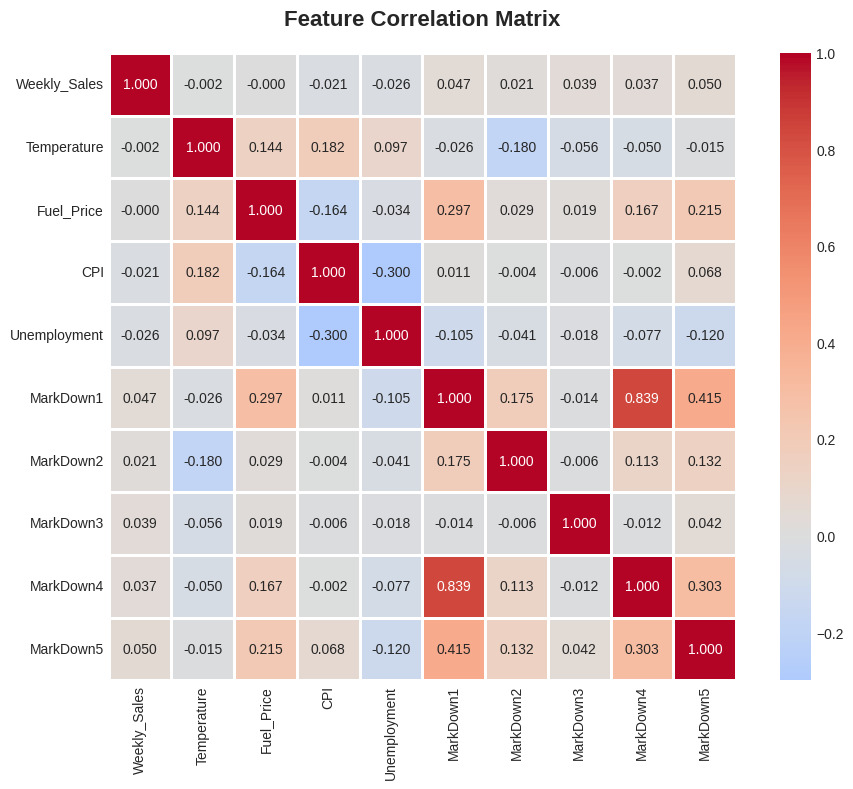


Correlations with Weekly_Sales:
Weekly_Sales    1.000000
MarkDown5       0.050465
MarkDown1       0.047172
MarkDown3       0.038562
MarkDown4       0.037467
MarkDown2       0.020716
Fuel_Price     -0.000120
Temperature    -0.002312
CPI            -0.020921
Unemployment   -0.025864
Name: Weekly_Sales, dtype: float64


In [10]:
numeric_df = df.select_dtypes(include=[np.number])

corr_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
corr_cols.extend([col for col in df.columns if 'MarkDown' in col])
corr_cols = [col for col in corr_cols if col in df.columns]

plt.figure(figsize=(10, 8))
correlation_matrix = df[corr_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nCorrelations with Weekly_Sales:")
print(correlation_matrix['Weekly_Sales'].sort_values(ascending=False))

## Step 4: Feature Engineering

Creating time-based features and lag values for better predictions.

In [13]:
df_features = df.copy()

df_features = df_features.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

df_features['Year'] = df_features['Date'].dt.year
df_features['Month'] = df_features['Date'].dt.month
df_features['Week'] = df_features['Date'].dt.isocalendar().week
df_features['Quarter'] = df_features['Date'].dt.quarter
df_features['DayOfYear'] = df_features['Date'].dt.dayofyear

df_features['IsHoliday'] = df_features['IsHoliday'].astype(int)


for lag in [1, 2, 3, 4]:
    df_features[f'Sales_Lag_{lag}'] = df_features.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(lag)


for window in [4, 8, 12]:
    df_features[f'Rolling_Mean_{window}'] = df_features.groupby(['Store', 'Dept'])['Sales_Lag_1'].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )
    df_features[f'Rolling_Std_{window}'] = df_features.groupby(['Store', 'Dept'])['Sales_Lag_1'].transform(
        lambda x: x.rolling(window=window, min_periods=1).std()
    )


df_features['EMA_4'] = df_features.groupby(['Store', 'Dept'])['Sales_Lag_1'].transform(
    lambda x: x.ewm(span=4, adjust=False).mean()
)

initial_rows = len(df_features)
df_features = df_features.dropna()
dropped_rows = initial_rows - len(df_features)

print(f" Dropped {dropped_rows:,} rows with missing lag values")
print(f"Final dataset shape: {df_features.shape}")

 Dropped 13,134 rows with missing lag values
Final dataset shape: (408436, 32)


##  Step 5: Seasonal Decomposition

Breaking down the time series into trend, seasonal, and residual components.

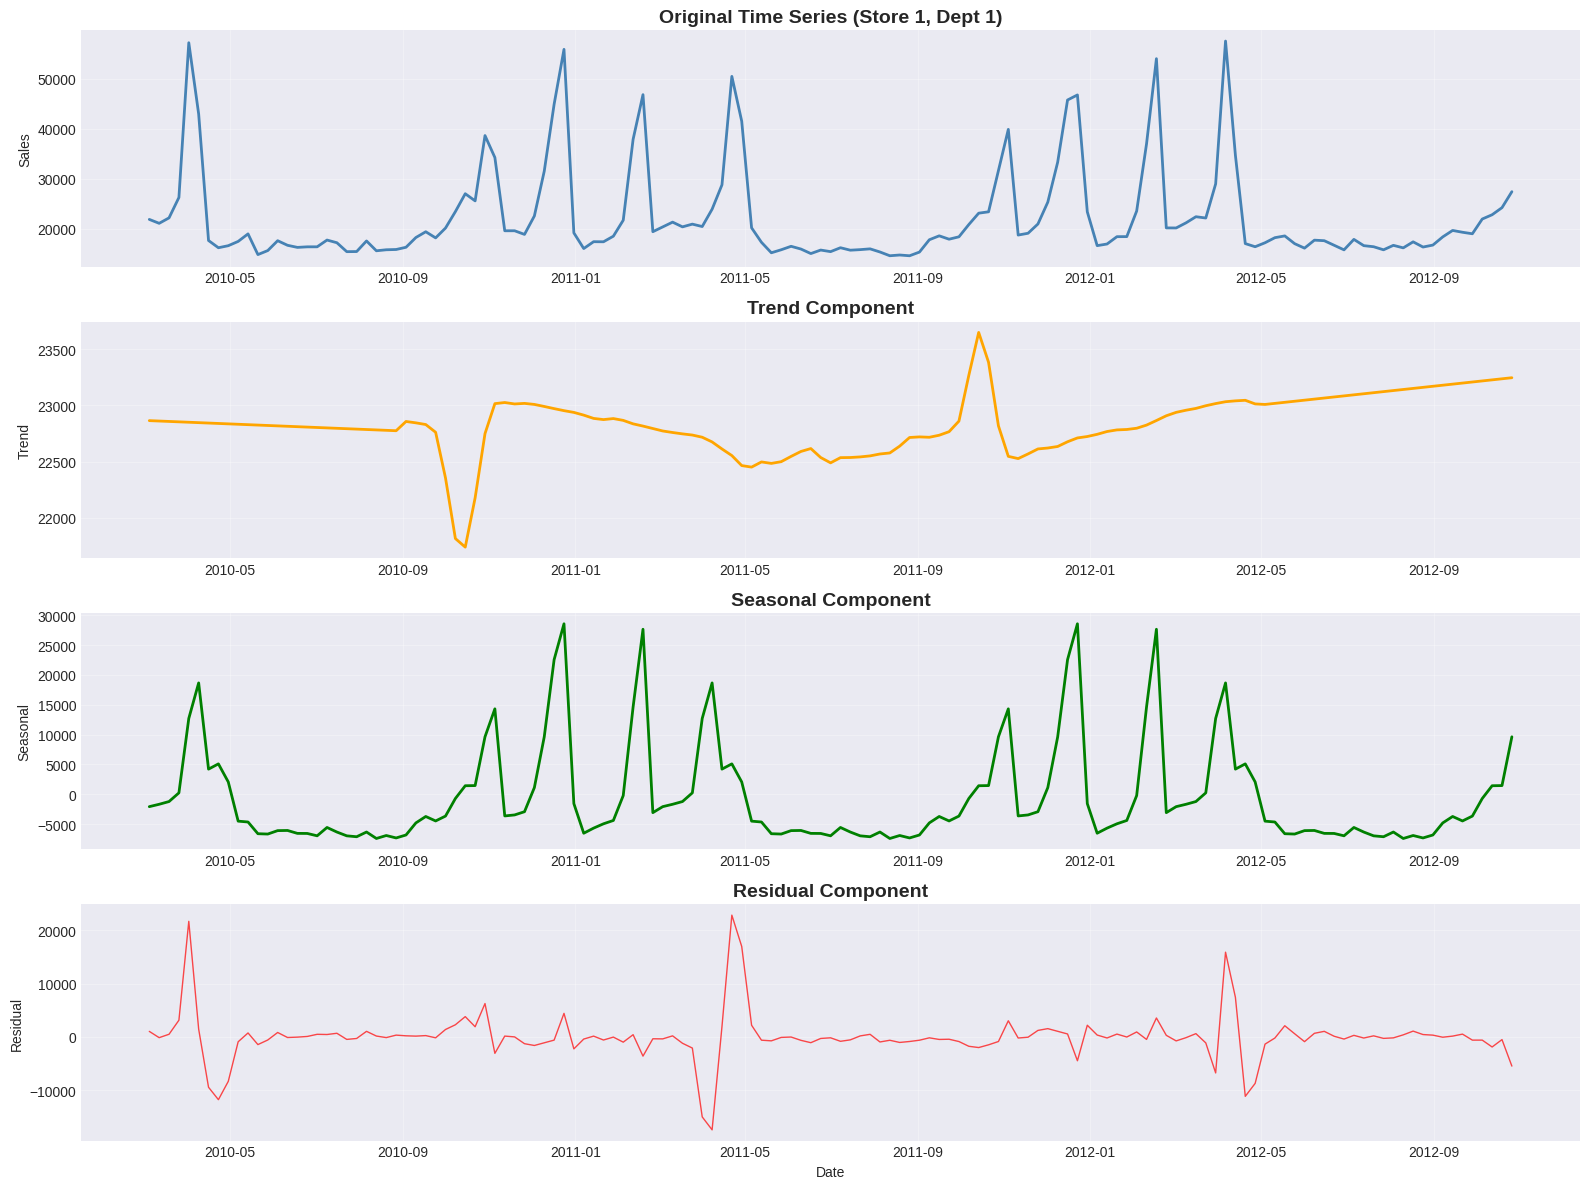


 Insights:
  - Trend: Overall direction of sales over time
  - Seasonal: Repeating patterns (yearly cycles)
  - Residual: Random fluctuations after removing trend and seasonality


In [14]:
store_1_data = df_features[df_features['Store'] == 1].copy()
dept_1_data = store_1_data[store_1_data['Dept'] == 1].copy()

if len(dept_1_data) > 52:
    dept_1_data = dept_1_data.set_index('Date')
    dept_1_data = dept_1_data.sort_index()

    decomposition = seasonal_decompose(dept_1_data['Weekly_Sales'],
                                       model='additive',
                                       period=52,
                                       extrapolate_trend='freq')

    fig, axes = plt.subplots(4, 1, figsize=(16, 12))

    # Original
    axes[0].plot(decomposition.observed, color='steelblue', linewidth=2)
    axes[0].set_title('Original Time Series (Store 1, Dept 1)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Sales')
    axes[0].grid(alpha=0.3)

    # Trend
    axes[1].plot(decomposition.trend, color='orange', linewidth=2)
    axes[1].set_title('Trend Component', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Trend')
    axes[1].grid(alpha=0.3)

    # Seasonal
    axes[2].plot(decomposition.seasonal, color='green', linewidth=2)
    axes[2].set_title('Seasonal Component', fontsize=14, fontweight='bold')
    axes[2].set_ylabel('Seasonal')
    axes[2].grid(alpha=0.3)

    # Residual
    axes[3].plot(decomposition.resid, color='red', linewidth=1, alpha=0.7)
    axes[3].set_title('Residual Component', fontsize=14, fontweight='bold')
    axes[3].set_ylabel('Residual')
    axes[3].set_xlabel('Date')
    axes[3].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n Insights:")
    print("  - Trend: Overall direction of sales over time")
    print("  - Seasonal: Repeating patterns (yearly cycles)")
    print("  - Residual: Random fluctuations after removing trend and seasonality")
else:
    print("Not enough data for seasonal decomposition (need at least 52 weeks)")

## Step 6: Prepare Data for Modeling

In [15]:
base_features = ['Store', 'Dept', 'IsHoliday', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
time_features = ['Year', 'Month', 'Week', 'Quarter', 'DayOfYear']
lag_features = ['Sales_Lag_1', 'Sales_Lag_2', 'Sales_Lag_3', 'Sales_Lag_4']
rolling_features = [f'Rolling_Mean_{w}' for w in [4, 8, 12]] + [f'Rolling_Std_{w}' for w in [4, 8, 12]]
ema_features = ['EMA_4']

markdown_features = [col for col in df_features.columns if 'MarkDown' in col]

feature_columns = base_features + time_features + lag_features + rolling_features + ema_features + markdown_features

feature_columns = [col for col in feature_columns if col in df_features.columns]

X = df_features[feature_columns]
y = df_features['Weekly_Sales']
dates = df_features['Date']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures used ({len(feature_columns)}):")
for i, feat in enumerate(feature_columns, 1):
    print(f"  {i:2d}. {feat}")


sort_idx = dates.argsort()
X = X.iloc[sort_idx]
y = y.iloc[sort_idx]
dates = dates.iloc[sort_idx]

split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_train, dates_test = dates.iloc[:split_idx], dates.iloc[split_idx:]

print(f"\nTraining set: {X_train.shape}")
print(f"   Dates: {dates_train.min()} to {dates_train.max()}")
print(f" Test set: {X_test.shape}")
print(f"   Dates: {dates_test.min()} to {dates_test.max()}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Features shape: (408436, 28)
Target shape: (408436,)

Features used (28):
   1. Store
   2. Dept
   3. IsHoliday
   4. Temperature
   5. Fuel_Price
   6. CPI
   7. Unemployment
   8. Year
   9. Month
  10. Week
  11. Quarter
  12. DayOfYear
  13. Sales_Lag_1
  14. Sales_Lag_2
  15. Sales_Lag_3
  16. Sales_Lag_4
  17. Rolling_Mean_4
  18. Rolling_Mean_8
  19. Rolling_Mean_12
  20. Rolling_Std_4
  21. Rolling_Std_8
  22. Rolling_Std_12
  23. EMA_4
  24. MarkDown1
  25. MarkDown2
  26. MarkDown3
  27. MarkDown4
  28. MarkDown5

Training set: (326748, 28)
   Dates: 2010-03-05 00:00:00 to 2012-04-20 00:00:00
 Test set: (81688, 28)
   Dates: 2012-04-20 00:00:00 to 2012-10-26 00:00:00


## Step 7: Train Regression Models

In [16]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr_train = lr_model.predict(X_train_scaled)
y_pred_lr_test = lr_model.predict(X_test_scaled)

lr_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_lr_train))
lr_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr_test))
lr_train_mae = mean_absolute_error(y_train, y_pred_lr_train)
lr_test_mae = mean_absolute_error(y_test, y_pred_lr_test)
lr_train_r2 = r2_score(y_train, y_pred_lr_train)
lr_test_r2 = r2_score(y_test, y_pred_lr_test)

print("LINEAR REGRESSION RESULTS:")
print(f"\nTraining Set:")
print(f"  RMSE: {lr_train_rmse:,.2f}")
print(f"  MAE:  {lr_train_mae:,.2f}")
print(f"  R²:   {lr_train_r2:.4f}")
print(f"\nTest Set:")
print(f"  RMSE: {lr_test_rmse:,.2f}")
print(f"  MAE:  {lr_test_mae:,.2f}")
print(f"  R²:   {lr_test_r2:.4f}")

LINEAR REGRESSION RESULTS:

Training Set:
  RMSE: 6,352.88
  MAE:  2,203.12
  R²:   0.9231

Test Set:
  RMSE: 3,224.11
  MAE:  1,631.69
  R²:   0.9785


In [17]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rf_model.fit(X_train, y_train)
y_pred_rf_train = rf_model.predict(X_train)
y_pred_rf_test = rf_model.predict(X_test)

rf_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
rf_train_mae = mean_absolute_error(y_train, y_pred_rf_train)
rf_test_mae = mean_absolute_error(y_test, y_pred_rf_test)
rf_train_r2 = r2_score(y_train, y_pred_rf_train)
rf_test_r2 = r2_score(y_test, y_pred_rf_test)

print("RANDOM FOREST RESULTS:")
print(f"\nTraining Set:")
print(f"  RMSE: {rf_train_rmse:,.2f}")
print(f"  MAE:  {rf_train_mae:,.2f}")
print(f"  R²:   {rf_train_r2:.4f}")
print(f"\nTest Set:")
print(f"  RMSE: {rf_test_rmse:,.2f}")
print(f"  MAE:  {rf_test_mae:,.2f}")
print(f"  R²:   {rf_test_r2:.4f}")

RANDOM FOREST RESULTS:

Training Set:
  RMSE: 2,898.30
  MAE:  1,361.69
  R²:   0.9840

Test Set:
  RMSE: 2,921.94
  MAE:  1,381.19
  R²:   0.9823


##  Step 8: Advanced Models


Training XGBoost and LightGBM with time-aware validation.

In [18]:
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train, y_train)

y_pred_xgb_train = xgb_model.predict(X_train)
y_pred_xgb_test = xgb_model.predict(X_test)

xgb_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_xgb_train))
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb_test))
xgb_train_mae = mean_absolute_error(y_train, y_pred_xgb_train)
xgb_test_mae = mean_absolute_error(y_test, y_pred_xgb_test)
xgb_train_r2 = r2_score(y_train, y_pred_xgb_train)
xgb_test_r2 = r2_score(y_test, y_pred_xgb_test)

print("XGBOOST RESULTS:")
print(f"\nTraining Set:")
print(f"  RMSE: {xgb_train_rmse:,.2f}")
print(f"  MAE:  {xgb_train_mae:,.2f}")
print(f"  R²:   {xgb_train_r2:.4f}")
print(f"\nTest Set:")
print(f"  RMSE: {xgb_test_rmse:,.2f}")
print(f"  MAE:  {xgb_test_mae:,.2f}")
print(f"  R²:   {xgb_test_r2:.4f}")

XGBOOST RESULTS:

Training Set:
  RMSE: 2,687.57
  MAE:  1,330.57
  R²:   0.9862

Test Set:
  RMSE: 2,844.81
  MAE:  1,366.32
  R²:   0.9833


In [19]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=100,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_model.fit(X_train, y_train)
y_pred_lgb_train = lgb_model.predict(X_train)
y_pred_lgb_test = lgb_model.predict(X_test)

lgb_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_lgb_train))
lgb_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgb_test))
lgb_train_mae = mean_absolute_error(y_train, y_pred_lgb_train)
lgb_test_mae = mean_absolute_error(y_test, y_pred_lgb_test)
lgb_train_r2 = r2_score(y_train, y_pred_lgb_train)
lgb_test_r2 = r2_score(y_test, y_pred_lgb_test)

print("LIGHTGBM RESULTS:")
print(f"\nTraining Set:")
print(f"  RMSE:{lgb_train_rmse:,.2f}")
print(f"  MAE:  {lgb_train_mae:,.2f}")
print(f"  R²:   {lgb_train_r2:.4f}")
print(f"\nTest Set:")
print(f"  RMSE: {lgb_test_rmse:,.2f}")
print(f"  MAE:  {lgb_test_mae:,.2f}")
print(f"  R²:   {lgb_test_r2:.4f}")

LIGHTGBM RESULTS:

Training Set:
  RMSE:3,611.50
  MAE:  1,588.58
  R²:   0.9751

Test Set:
  RMSE: 3,054.30
  MAE:  1,464.24
  R²:   0.9807


## Step 9: Model Comparison

MODEL COMPARISON (Test Set Performance)
            Model   Test RMSE    Test MAE  Test R²
Linear Regression 3224.109069 1631.685006 0.978487
    Random Forest 2921.941014 1381.190288 0.982330
          XGBoost 2844.806770 1366.322070 0.983251
         LightGBM 3054.295064 1464.239945 0.980693

Best Model: XGBoost (R² = 0.9833)


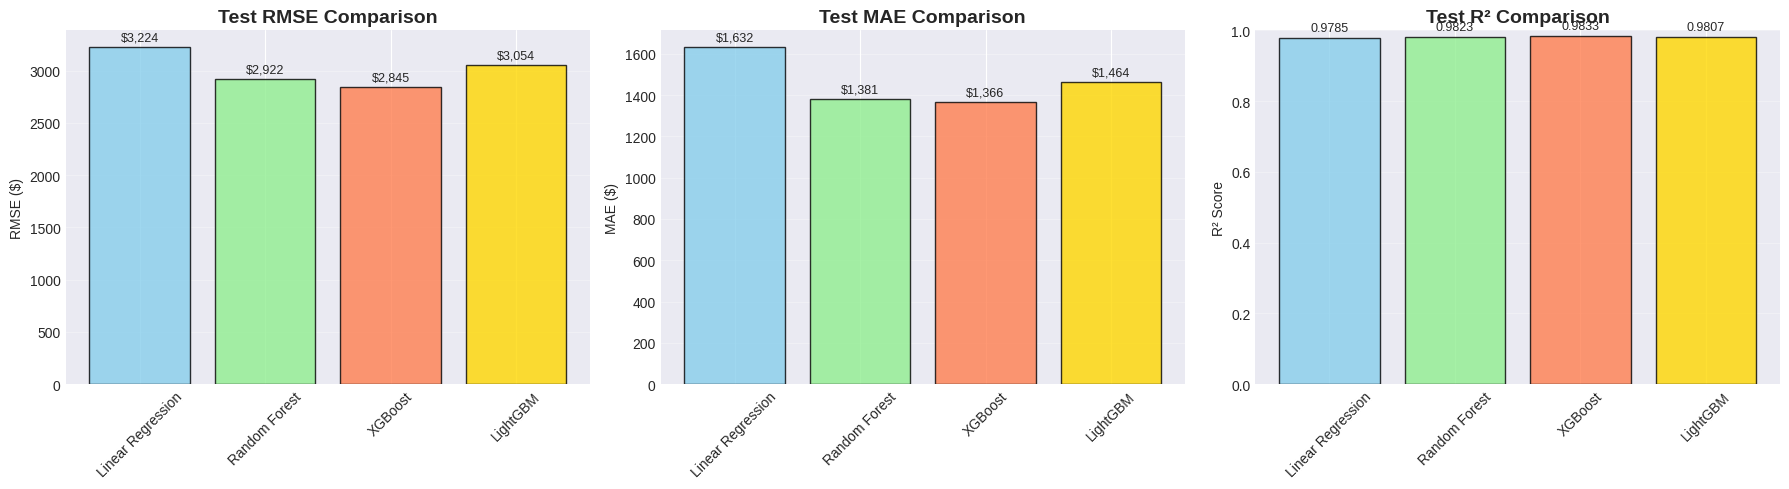

In [20]:
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost', 'LightGBM'],
    'Test RMSE': [lr_test_rmse, rf_test_rmse, xgb_test_rmse, lgb_test_rmse],
    'Test MAE': [lr_test_mae, rf_test_mae, xgb_test_mae, lgb_test_mae],
    'Test R²': [lr_test_r2, rf_test_r2, xgb_test_r2, lgb_test_r2]
})

print("MODEL COMPARISON (Test Set Performance)")
print(results_df.to_string(index=False))

best_idx = results_df['Test R²'].idxmax()
best_model = results_df.loc[best_idx, 'Model']
best_r2 = results_df.loc[best_idx, 'Test R²']

print(f"\nBest Model: {best_model} (R² = {best_r2:.4f})")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(results_df['Model'], results_df['Test RMSE'],
            color=['skyblue', 'lightgreen', 'coral', 'gold'], alpha=0.8, edgecolor='black')
axes[0].set_title('Test RMSE Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('RMSE ($)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(results_df['Test RMSE']):
    axes[0].text(i, v + max(results_df['Test RMSE'])*0.02, f'${v:,.0f}',
                 ha='center', fontsize=9)

axes[1].bar(results_df['Model'], results_df['Test MAE'],
            color=['skyblue', 'lightgreen', 'coral', 'gold'], alpha=0.8, edgecolor='black')
axes[1].set_title('Test MAE Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('MAE ($)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(results_df['Test MAE']):
    axes[1].text(i, v + max(results_df['Test MAE'])*0.02, f'${v:,.0f}',
                 ha='center', fontsize=9)

axes[2].bar(results_df['Model'], results_df['Test R²'],
            color=['skyblue', 'lightgreen', 'coral', 'gold'], alpha=0.8, edgecolor='black')
axes[2].set_title('Test R² Comparison', fontsize=14, fontweight='bold')
axes[2].set_ylabel('R² Score')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_ylim([0, 1])
axes[2].grid(axis='y', alpha=0.3)
for i, v in enumerate(results_df['Test R²']):
    axes[2].text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Step 10: Visualize Predictions vs Actual

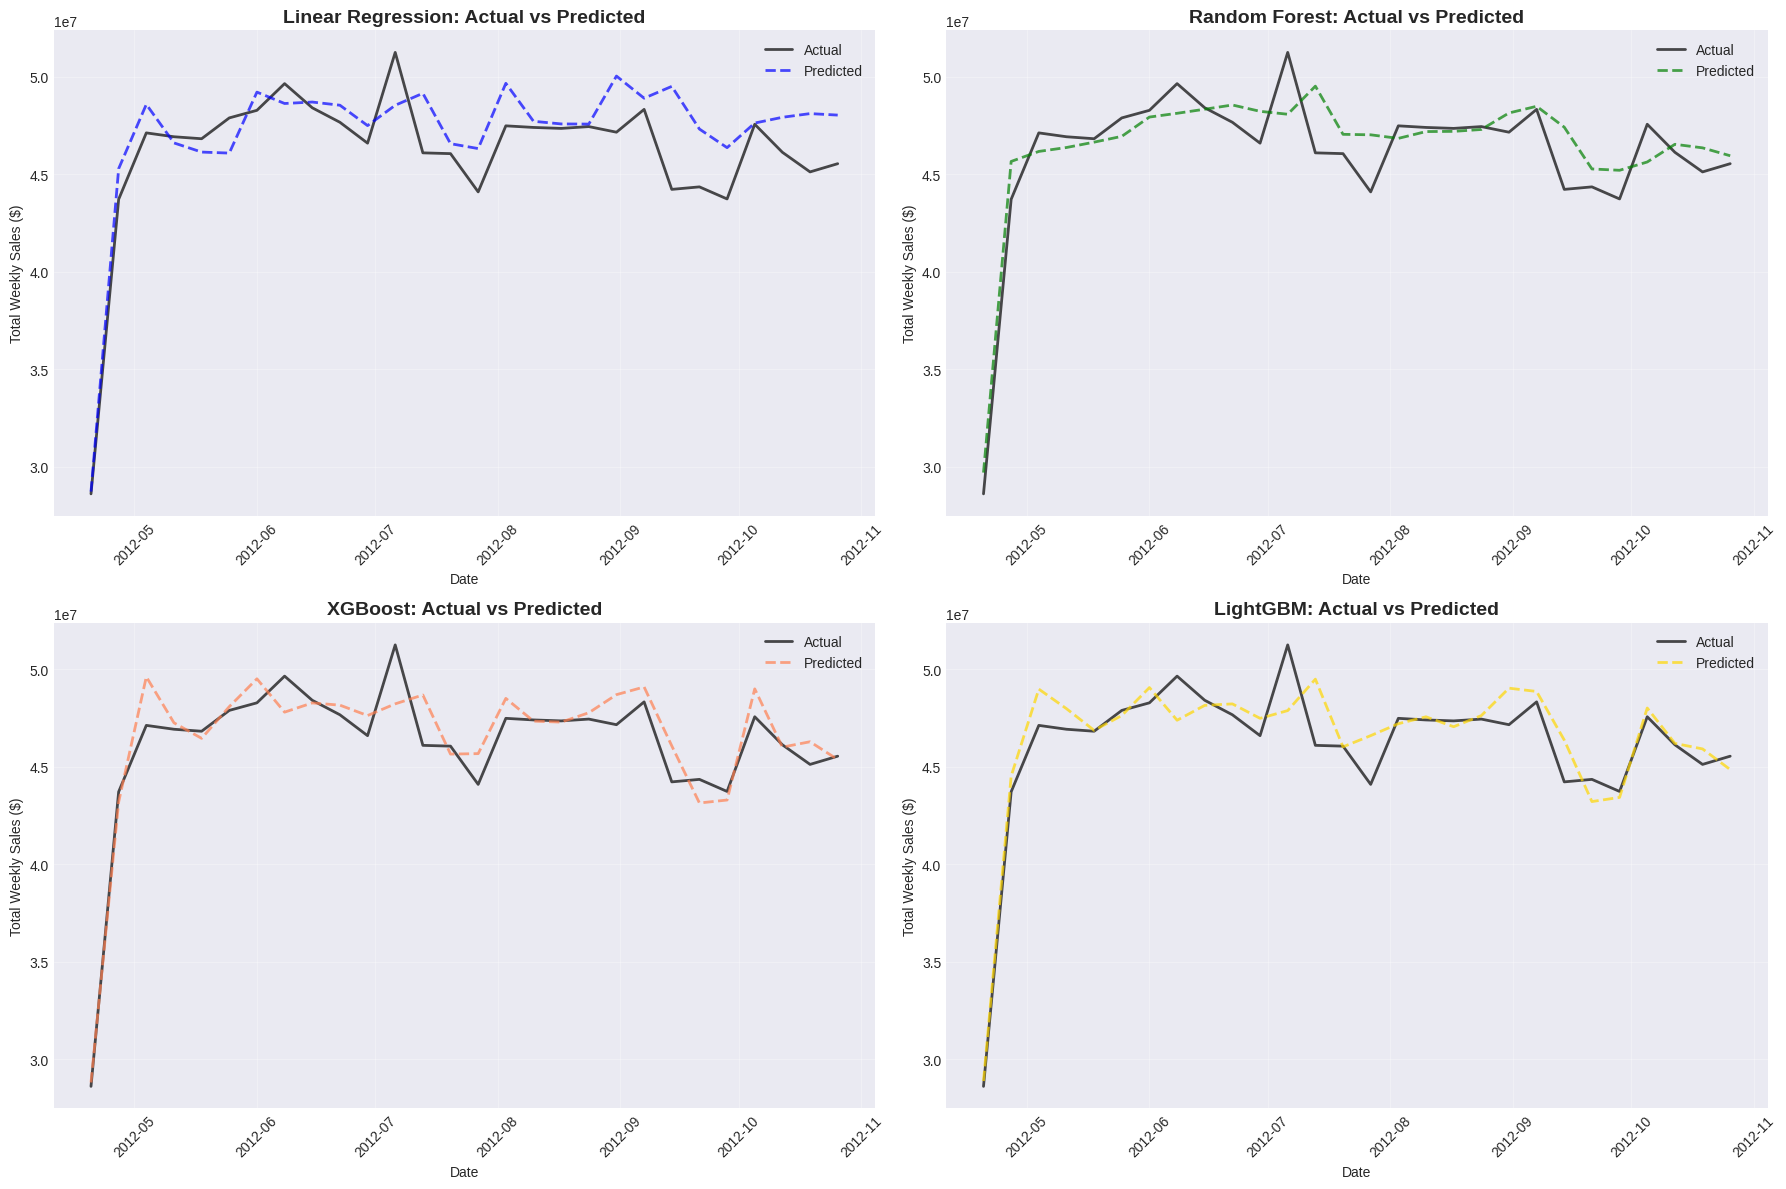

In [21]:
test_results = pd.DataFrame({
    'Date': dates_test.values,
    'Actual': y_test.values,
    'LR_Pred': y_pred_lr_test,
    'RF_Pred': y_pred_rf_test,
    'XGB_Pred': y_pred_xgb_test,
    'LGB_Pred': y_pred_lgb_test
})

daily_comparison = test_results.groupby('Date').sum().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

axes[0, 0].plot(daily_comparison['Date'], daily_comparison['Actual'],
                label='Actual', linewidth=2, color='black', alpha=0.7)
axes[0, 0].plot(daily_comparison['Date'], daily_comparison['LR_Pred'],
                label='Predicted', linewidth=2, color='blue', alpha=0.7, linestyle='--')
axes[0, 0].set_title('Linear Regression: Actual vs Predicted', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Total Weekly Sales ($)')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

axes[0, 1].plot(daily_comparison['Date'], daily_comparison['Actual'],
                label='Actual', linewidth=2, color='black', alpha=0.7)
axes[0, 1].plot(daily_comparison['Date'], daily_comparison['RF_Pred'],
                label='Predicted', linewidth=2, color='green', alpha=0.7, linestyle='--')
axes[0, 1].set_title('Random Forest: Actual vs Predicted', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Total Weekly Sales ($)')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

axes[1, 0].plot(daily_comparison['Date'], daily_comparison['Actual'],
                label='Actual', linewidth=2, color='black', alpha=0.7)
axes[1, 0].plot(daily_comparison['Date'], daily_comparison['XGB_Pred'],
                label='Predicted', linewidth=2, color='coral', alpha=0.7, linestyle='--')
axes[1, 0].set_title('XGBoost: Actual vs Predicted', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Total Weekly Sales ($)')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

axes[1, 1].plot(daily_comparison['Date'], daily_comparison['Actual'],
                label='Actual', linewidth=2, color='black', alpha=0.7)
axes[1, 1].plot(daily_comparison['Date'], daily_comparison['LGB_Pred'],
                label='Predicted', linewidth=2, color='gold', alpha=0.7, linestyle='--')
axes[1, 1].set_title('LightGBM: Actual vs Predicted', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Total Weekly Sales ($)')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

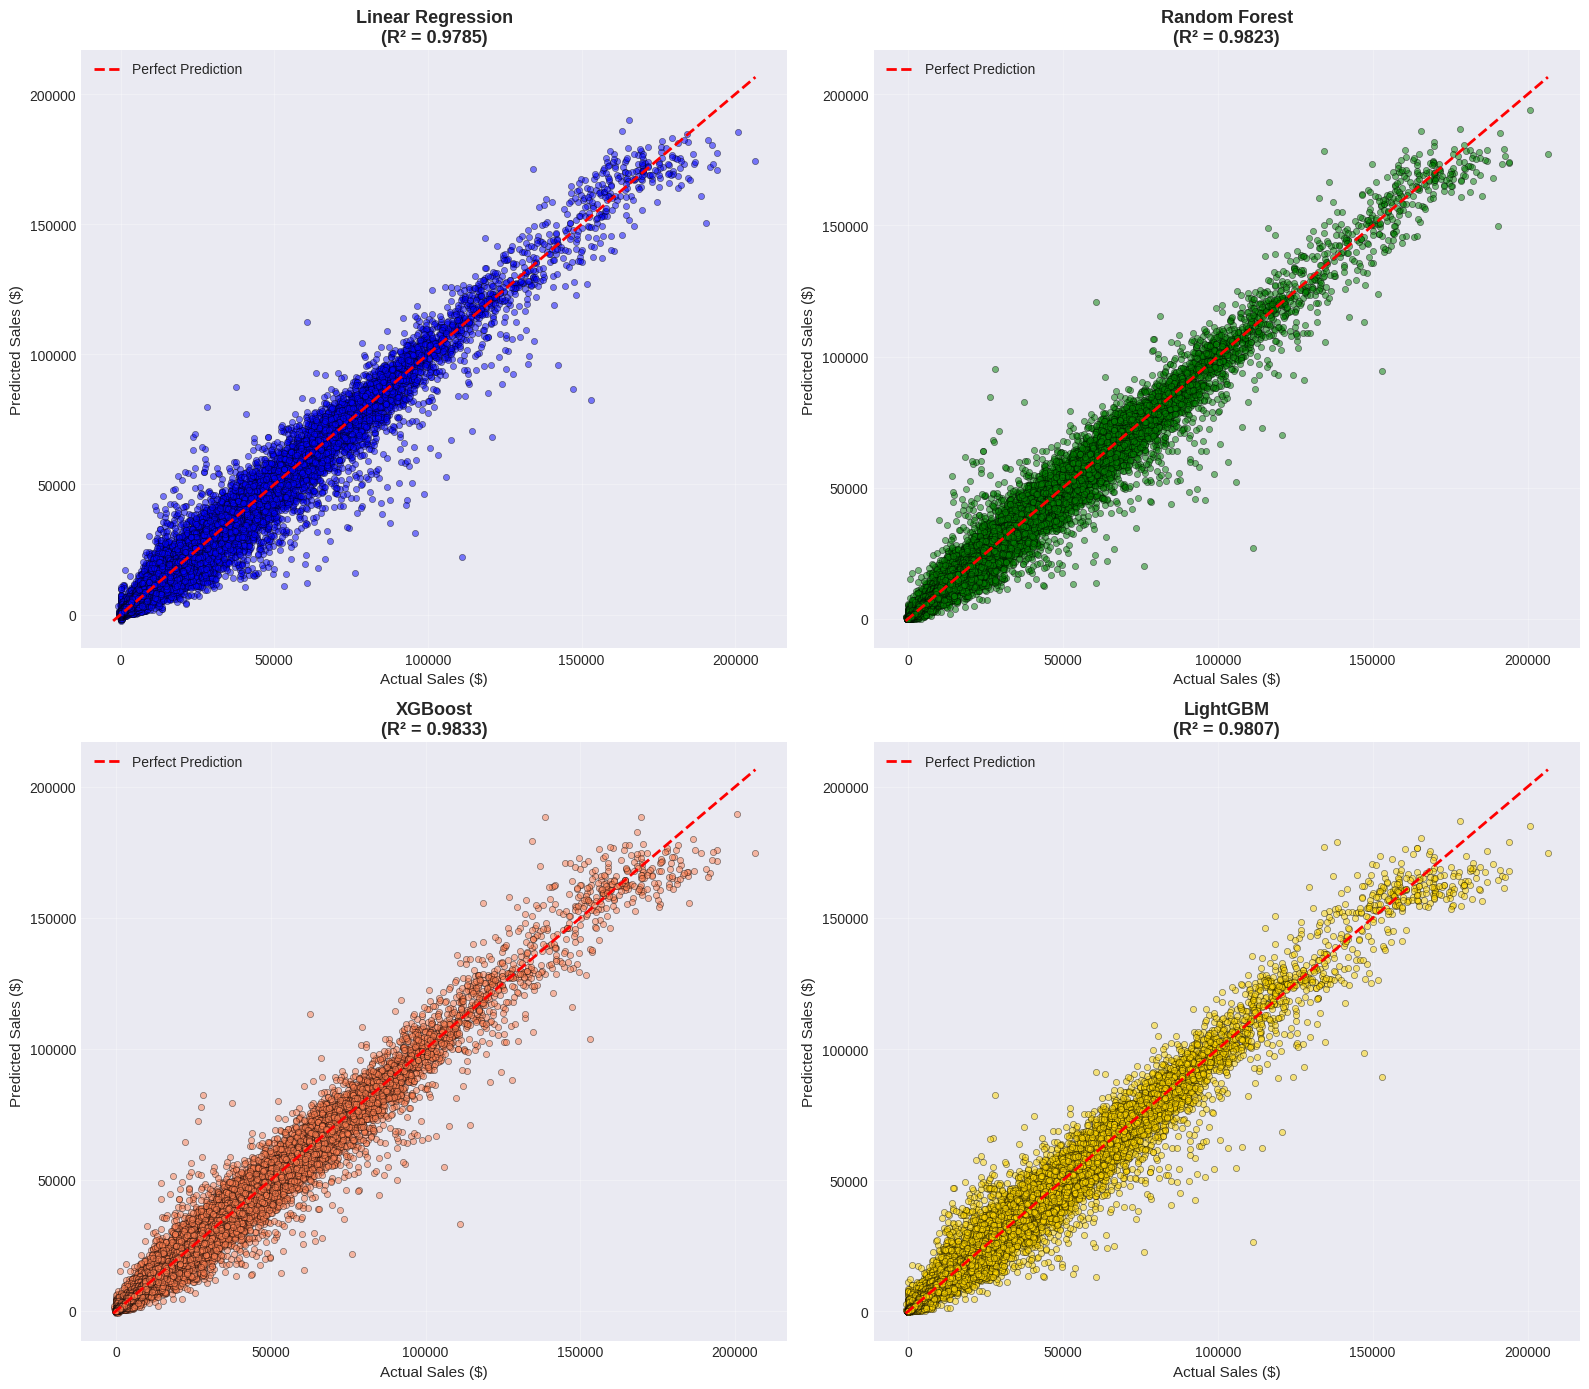


Interpretation:
  - Points closer to the red line indicate better predictions
  - Higher R² means better model fit


In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

models_data = [
    ('Linear Regression', y_pred_lr_test, 'blue'),
    ('Random Forest', y_pred_rf_test, 'green'),
    ('XGBoost', y_pred_xgb_test, 'coral'),
    ('LightGBM', y_pred_lgb_test, 'gold')
]

for idx, (name, predictions, color) in enumerate(models_data):
    ax = axes[idx // 2, idx % 2]

    ax.scatter(y_test, predictions, alpha=0.5, s=20, color=color, edgecolors='black', linewidth=0.5)

    min_val = min(y_test.min(), predictions.min())
    max_val = max(y_test.max(), predictions.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

    r2 = r2_score(y_test, predictions)

    ax.set_title(f'{name}\n(R² = {r2:.4f})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Actual Sales ($)', fontsize=11)
    ax.set_ylabel('Predicted Sales ($)', fontsize=11)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  - Points closer to the red line indicate better predictions")
print("  - Higher R² means better model fit")

## Step 11: Feature Importance Analysis

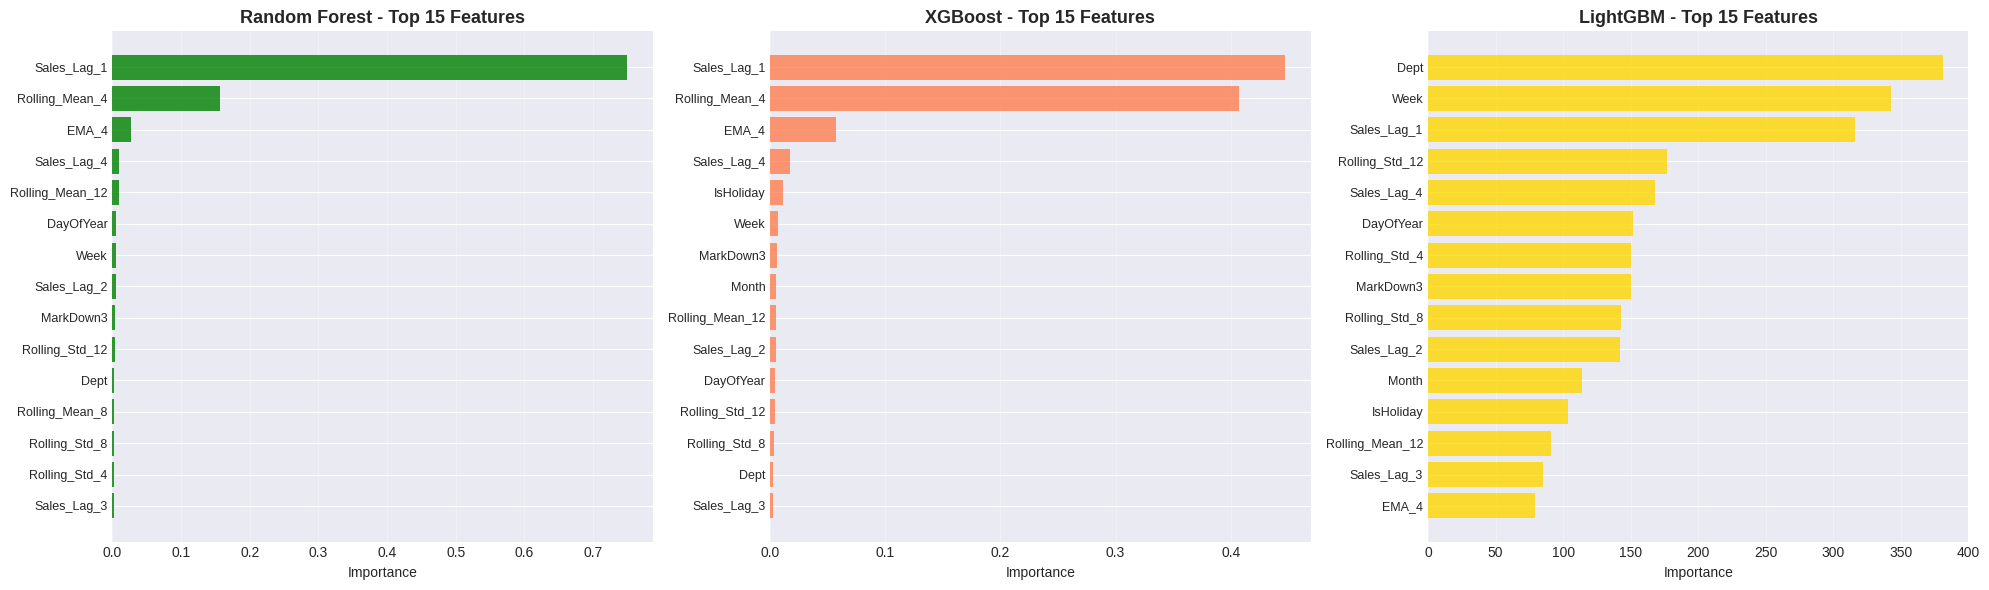


Top 5 Most Important Features:

Random Forest:
        feature  importance
    Sales_Lag_1    0.749547
 Rolling_Mean_4    0.156765
          EMA_4    0.027429
    Sales_Lag_4    0.010364
Rolling_Mean_12    0.009170

XGBoost:
       feature  importance
   Sales_Lag_1    0.447000
Rolling_Mean_4    0.406884
         EMA_4    0.056985
   Sales_Lag_4    0.017202
     IsHoliday    0.011270

LightGBM:
       feature  importance
          Dept         381
          Week         343
   Sales_Lag_1         316
Rolling_Std_12         177
   Sales_Lag_4         168


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

rf_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

axes[0].barh(range(len(rf_importance)), rf_importance['importance'], color='green', alpha=0.8)
axes[0].set_yticks(range(len(rf_importance)))
axes[0].set_yticklabels(rf_importance['feature'], fontsize=9)
axes[0].set_xlabel('Importance')
axes[0].set_title('Random Forest - Top 15 Features', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

xgb_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

axes[1].barh(range(len(xgb_importance)), xgb_importance['importance'], color='coral', alpha=0.8)
axes[1].set_yticks(range(len(xgb_importance)))
axes[1].set_yticklabels(xgb_importance['feature'], fontsize=9)
axes[1].set_xlabel('Importance')
axes[1].set_title('XGBoost - Top 15 Features', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

lgb_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

axes[2].barh(range(len(lgb_importance)), lgb_importance['importance'], color='gold', alpha=0.8)
axes[2].set_yticks(range(len(lgb_importance)))
axes[2].set_yticklabels(lgb_importance['feature'], fontsize=9)
axes[2].set_xlabel('Importance')
axes[2].set_title('LightGBM - Top 15 Features', fontsize=13, fontweight='bold')
axes[2].invert_yaxis()
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print("\nRandom Forest:")
print(rf_importance.head().to_string(index=False))
print("\nXGBoost:")
print(xgb_importance.head().to_string(index=False))
print("\nLightGBM:")
print(lgb_importance.head().to_string(index=False))

## Step 12: Final Summary & Conclusions

In [24]:
print("\n Dataset Overview:")
print(f"  • Total records: {len(df):,}")
print(f"  • Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"  • Number of stores: {df['Store'].nunique()}")
print(f"  • Number of departments: {df['Dept'].nunique()}")
print(f"  • Average weekly sales: ${df['Weekly_Sales'].mean():,.2f}")
print(f"  • Total sales in dataset: ${df['Weekly_Sales'].sum():,.2f}")

print("\nFeature Engineering:")
print(f"  • Total features created: {len(feature_columns)}")
print("  • Time-based features: Year, Month, Week, Quarter, DayOfYear")
print("  • Lag features: 1, 2, 3, 4 weeks")
print("  • Rolling statistics: 4, 8, 12 week windows")
print("  • Advanced: Exponential Moving Average")

print("\nModels Trained:")
print(" Linear Regression (baseline)")
print("  Random Forest Regressor")
print("  XGBoost (gradient boosting)")
print("  LightGBM (gradient boosting)")

print("\n Model Performance (Test Set):")
print(results_df.to_string(index=False))

print(f"\nBest Performing Model: {best_model}")
print(f"   • Test R²: {best_r2:.4f}")
print(f"   • Test RMSE: ${results_df.loc[best_idx, 'Test RMSE']:,.2f}")
print(f"   • Test MAE: ${results_df.loc[best_idx, 'Test MAE']:,.2f}")

print("\nKey Insights:")
print("  • Lag features are highly important for sales forecasting")
print("  • Rolling averages capture recent trends effectively")
print("  • Tree-based models (RF, XGB, LGB) outperform linear regression")
print("  • Time-based validation is crucial for time series data")
print("  • Store and department IDs are significant predictors")

print("\n Techniques Demonstrated:")
print("  Time series forecasting")
print("  Feature engineering (time-based, lag, rolling)")
print("  Regression modeling")
print("  Seasonal decomposition")
print("  Time-aware train-test split")
print("  Multiple model comparison")
print("  Feature importance analysis")
print("  Actual vs predicted visualization")

print("\nNext Steps & Improvements:")
print("  • Implement ARIMA or Prophet for pure time series approach")
print("  • Add external features (weather, promotions, events)")
print("  • Perform hyperparameter tuning with time series CV")
print("  • Create separate models for each store/department")
print("  • Ensemble multiple models for better predictions")
print("  • Implement rolling forecast strategy")


 Dataset Overview:
  • Total records: 421,570
  • Date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00
  • Number of stores: 45
  • Number of departments: 81
  • Average weekly sales: $15,981.26
  • Total sales in dataset: $6,737,218,987.11

Feature Engineering:
  • Total features created: 28
  • Time-based features: Year, Month, Week, Quarter, DayOfYear
  • Lag features: 1, 2, 3, 4 weeks
  • Rolling statistics: 4, 8, 12 week windows
  • Advanced: Exponential Moving Average

Models Trained:
 Linear Regression (baseline)
  Random Forest Regressor
  XGBoost (gradient boosting)
  LightGBM (gradient boosting)

 Model Performance (Test Set):
            Model   Test RMSE    Test MAE  Test R²
Linear Regression 3224.109069 1631.685006 0.978487
    Random Forest 2921.941014 1381.190288 0.982330
          XGBoost 2844.806770 1366.322070 0.983251
         LightGBM 3054.295064 1464.239945 0.980693

Best Performing Model: XGBoost
   • Test R²: 0.9833
   • Test RMSE: $2,844.81
   • Test MAE: $1,